<h1> <b> Configuraciones y rutas

In [ ]:
# Liberías
import sys
import copy
import torch
import torch.nn as nn
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             f1_score, recall_score, precision_score)
sys.path.append(str(Path("..").resolve()))
from federado.modelo import crear_modelo
from torch.utils.data import random_split
from sklearn.metrics import roc_curve
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression

# Semilla
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

# DEVICE
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


In [ ]:
# Rutas por centro
BASE_DIR = Path("..")

# Datos preprocesados por centro
CENTROS = {
    "center_1": {
        "train": BASE_DIR / "preprocesamiento/output/center_1/preprocesamiento_train",
        "test" : BASE_DIR / "preprocesamiento/output/center_1/preprocesamiento_test",
    },
    "center_2": {
        "train": BASE_DIR / "preprocesamiento/output/center_2/preprocesamiento_train",
        "test" : BASE_DIR / "preprocesamiento/output/center_2/preprocesamiento_test",
    },
    "center_3": {
        "train": BASE_DIR / "preprocesamiento/output/center_3/preprocesamiento_train",
        "test" : BASE_DIR / "preprocesamiento/output/center_3/preprocesamiento_test",
    },
    "center_4": {
        "train": BASE_DIR / "preprocesamiento/output/center_4/preprocesamiento_train",
        "test" : BASE_DIR / "preprocesamiento/output/center_4/preprocesamiento_test",
    },
}

# Modelo global federado entrenado
MODELO_GLOBAL_PATH = BASE_DIR / "federado/pesos/modelo_fedadaptativo_mejor.pth"

# Salida de adaptadores locales
ADAPTADORES_DIR = Path("adaptadores")
ADAPTADORES_DIR.mkdir(exist_ok=True)

# Hiperparámetros de adaptación
BATCH_SIZE   = 16
EPOCHS_ADAPT = 20    # pocas épocas para evitar sobreajuste
LR_ADAPT     = 1e-3  # lr más alto — solo entrenamos pocas capas

# Verificar que los centros existen
for nombre, rutas in CENTROS.items():
    train_ok = rutas["train"].exists()
    test_ok  = rutas["test"].exists()
    print(f"  {nombre} — train: {'Ok' if train_ok else 'Bad'} | test: {'Ok' if test_ok else 'Bad'}")

print(f"\nModelo global: {'Ok' if MODELO_GLOBAL_PATH.exists() else 'Bad'}")

  center_1 — train: Ok | test: Ok
  center_2 — train: Ok | test: Ok
  center_3 — train: Ok | test: Ok
  center_4 — train: Ok | test: Ok

Modelo global: Ok


<h1><b> Dataset y carga por centro

In [36]:
# Dataset
class StrokeDataset(Dataset):
    def __init__(self, archivos):
        self.archivos = archivos

    def __len__(self):
        return len(self.archivos)

    def __getitem__(self, idx):
        ruta   = self.archivos[idx]
        imagen = np.load(ruta).astype(np.float32)
        imagen = torch.from_numpy(imagen)
        label  = 1 if "STROKE" in ruta.stem else 0
        return imagen, torch.tensor(label, dtype=torch.float32)

# Carga por centro
datos_centros = {}

for nombre, rutas in CENTROS.items():
    archivos_train = sorted(rutas["train"].glob("*.npy"))
    archivos_test  = sorted(rutas["test"].glob("*.npy"))

    datos_centros[nombre] = {
        "loader_train": DataLoader(StrokeDataset(archivos_train), batch_size=BATCH_SIZE, shuffle=True),
        "loader_test" : DataLoader(StrokeDataset(archivos_test),  batch_size=BATCH_SIZE, shuffle=False),
        "n_train"     : len(archivos_train),
        "n_test"      : len(archivos_test),
    }

# Verificación
print(f"{'Centro':<12} {'Train':>8} {'Test':>8}")
print("─" * 30)
for nombre, datos in datos_centros.items():
    print(f"{nombre:<12} {datos['n_train']:>8} {datos['n_test']:>8}")

Centro          Train     Test
──────────────────────────────
center_1         3040      760
center_2          960      240
center_3          679      171
center_4         1280      320


<h1><b> Cargar del modelo y congelamiento

In [37]:
# Cargar modelo global federado
encoder = crear_modelo().to(DEVICE)
encoder.load_state_dict(torch.load(MODELO_GLOBAL_PATH, map_location=DEVICE))

# Congelar todos los parámetros, el modelo no cambia
for param in encoder.parameters():
    param.requires_grad = False

encoder.eval()

# Verificación
total_params    = sum(p.numel() for p in encoder.parameters())
params_trainables = sum(p.numel() for p in encoder.parameters() if p.requires_grad)

print(f"Encoder cargado desde: {MODELO_GLOBAL_PATH}")
print(f"Parámetros totales   : {total_params:,}")
print(f"Parámetros congelados: {total_params - params_trainables:,}")
print(f"Parámetros entrenables: {params_trainables:,}")

Encoder cargado desde: ..\federado\pesos\modelo_global_mejor.pth
Parámetros totales   : 11,173,889
Parámetros congelados: 11,173,889
Parámetros entrenables: 0


<h1> <b> Adapatador local

In [38]:
class AdaptadorLocal(nn.Module):
    def __init__(self, encoder):
        super().__init__()

        # Encoder congelado — extrae features
        self.encoder = encoder

        # BatchNorm local — reescala las features al dominio del centro
        # aprende la media y std propias del centro
        self.bn = nn.BatchNorm1d(512)

        # Clasificador local — decide STROKE/CONTROL
        self.clasificador = nn.Linear(512, 1)

    def forward(self, x):
        # Extraer features con el encoder congelado
        with torch.no_grad():
            x = self.encoder.maxpool(self.encoder.relu(self.encoder.bn1(self.encoder.conv1(x))))
            x = self.encoder.layer1(x)
            x = self.encoder.layer2(x)
            x = self.encoder.layer3(x)
            x = self.encoder.layer4(x)
            x = self.encoder.avgpool(x).squeeze(-1).squeeze(-1)  # (batch, 512)

        # BatchNorm local — adapta al dominio del centro
        x = self.bn(x)

        # Clasificador local
        x = self.clasificador(x)
        return x


# Verificación con un batch de prueba
adaptador_prueba = AdaptadorLocal(encoder).to(DEVICE)

params_entrenables = sum(p.numel() for p in adaptador_prueba.parameters() if p.requires_grad)
print(f"Parámetros entrenables (adaptador): {params_entrenables:,}")
print(f"  BatchNorm  : {sum(p.numel() for p in adaptador_prueba.bn.parameters()):,}")
print(f"  Clasificador: {sum(p.numel() for p in adaptador_prueba.clasificador.parameters()):,}")

Parámetros entrenables (adaptador): 1,537
  BatchNorm  : 1,024
  Clasificador: 513


<h1><b> Entrenamiento del adaptador por centro

In [39]:
def entrenar_adaptador(nombre, encoder, loader_train, loader_val, epochs):
    """
    Entrena solo el BatchNorm y clasificador local.
    """
    adaptador = AdaptadorLocal(encoder).to(DEVICE)
    criterio  = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, adaptador.parameters()),
        lr=LR_ADAPT
    )

    mejor_val_loss = float("inf")
    mejor_estado   = None

    for epoca in range(epochs):
        # Train
        adaptador.train()
        train_loss, train_correctos = 0.0, 0

        for imagenes, labels in loader_train:
            imagenes = imagenes.to(DEVICE)
            labels   = labels.to(DEVICE).unsqueeze(1)
            optimizer.zero_grad()
            salida = adaptador(imagenes)
            loss   = criterio(salida, labels)
            loss.backward()
            optimizer.step()
            train_loss      += loss.item()
            preds            = (torch.sigmoid(salida) >= 0.5).float()
            train_correctos += (preds == labels).sum().item()

        # Val
        adaptador.eval()
        val_loss, val_correctos = 0.0, 0

        with torch.no_grad():
            for imagenes, labels in loader_val:
                imagenes = imagenes.to(DEVICE)
                labels   = labels.to(DEVICE).unsqueeze(1)
                salida   = adaptador(imagenes)
                loss     = criterio(salida, labels)
                val_loss      += loss.item()
                preds          = (torch.sigmoid(salida) >= 0.5).float()
                val_correctos += (preds == labels).sum().item()

        train_loss /= len(loader_train)
        val_loss   /= len(loader_val)
        train_acc   = train_correctos / len(loader_train.dataset)
        val_acc     = val_correctos   / len(loader_val.dataset)

        print(f"  [{nombre}] época {epoca+1:02d}/{epochs} — "
              f"train_loss: {train_loss:.4f} acc: {train_acc:.4f} | "
              f"val_loss: {val_loss:.4f} acc: {val_acc:.4f}")

        if val_loss < mejor_val_loss:
            mejor_val_loss = val_loss
            mejor_estado   = copy.deepcopy(adaptador.state_dict())
            print(f"    → mejor época: {epoca+1}")

    adaptador.load_state_dict(mejor_estado)
    torch.save(mejor_estado, ADAPTADORES_DIR / f"{nombre}_adaptador.pth")
    return adaptador

In [40]:
# Split 80/20 del train por centro
adaptadores = {}

for nombre, datos in datos_centros.items():
    archivos_train = sorted(CENTROS[nombre]["train"].glob("*.npy"))
    dataset_train  = StrokeDataset(archivos_train)

    val_size   = int(len(dataset_train) * 0.2)
    train_size = len(dataset_train) - val_size
    train_split, val_split = random_split(dataset_train, [train_size, val_size],
                                          generator=torch.Generator().manual_seed(SEED))

    loader_train = DataLoader(train_split, batch_size=BATCH_SIZE, shuffle=True)
    loader_val   = DataLoader(val_split,   batch_size=BATCH_SIZE, shuffle=False)

    print(f"\n{'='*50}")
    print(f"  Centro: {nombre} — train: {train_size} | val: {val_size}")
    print(f"{'='*50}")

    adaptadores[nombre] = entrenar_adaptador(
        nombre, encoder, loader_train, loader_val, EPOCHS_ADAPT
    )

print("\nTodos los adaptadores entrenados.")


  Centro: center_1 — train: 2432 | val: 608
  [center_1] época 01/20 — train_loss: 0.0368 acc: 0.9860 | val_loss: 0.0057 acc: 0.9984
    → mejor época: 1
  [center_1] época 02/20 — train_loss: 0.0039 acc: 1.0000 | val_loss: 0.0048 acc: 0.9984
    → mejor época: 2
  [center_1] época 03/20 — train_loss: 0.0015 acc: 1.0000 | val_loss: 0.0039 acc: 0.9984
    → mejor época: 3
  [center_1] época 04/20 — train_loss: 0.0029 acc: 0.9996 | val_loss: 0.0068 acc: 0.9967
  [center_1] época 05/20 — train_loss: 0.0026 acc: 0.9996 | val_loss: 0.0034 acc: 0.9984
    → mejor época: 5
  [center_1] época 06/20 — train_loss: 0.0035 acc: 0.9988 | val_loss: 0.0090 acc: 0.9967
  [center_1] época 07/20 — train_loss: 0.0027 acc: 0.9992 | val_loss: 0.0111 acc: 0.9967
  [center_1] época 08/20 — train_loss: 0.0012 acc: 1.0000 | val_loss: 0.0041 acc: 0.9984
  [center_1] época 09/20 — train_loss: 0.0010 acc: 1.0000 | val_loss: 0.0100 acc: 0.9967
  [center_1] época 10/20 — train_loss: 0.0035 acc: 0.9992 | val_loss: 

<h1><b>Evaluación

In [41]:
# Evaluación final
def evaluar_adaptador(nombre, adaptador, loader_test):
    adaptador.eval()
    todos_labels = []
    todos_probs  = []
    todos_preds  = []

    with torch.no_grad():
        for imagenes, labels in loader_test:
            imagenes = imagenes.to(DEVICE)
            salida   = adaptador(imagenes)
            probs    = torch.sigmoid(salida).squeeze(1).cpu().numpy()
            preds    = (probs >= 0.5).astype(int)
            todos_labels.extend(labels.numpy().astype(int))
            todos_probs.extend(probs)
            todos_preds.extend(preds)

    auc          = roc_auc_score(todos_labels, todos_probs)
    f1           = f1_score(todos_labels, todos_preds)
    sensibilidad  = recall_score(todos_labels, todos_preds)
    especificidad = recall_score(todos_labels, todos_preds, pos_label=0)
    precision    = precision_score(todos_labels, todos_preds)
    accuracy     = sum(p == l for p, l in zip(todos_preds, todos_labels)) / len(todos_labels)
    cm           = confusion_matrix(todos_labels, todos_preds)

    return {
        "auc"          : auc,
        "f1"           : f1,
        "sensibilidad" : sensibilidad,
        "especificidad": especificidad,
        "precision"    : precision,
        "accuracy"     : accuracy,
        "cm"           : cm,
        "labels"       : todos_labels,
        "preds"        : todos_preds,
    }


# Evaluar cada centro
resultados = {}
for nombre, datos in datos_centros.items():
    resultados[nombre] = evaluar_adaptador(nombre, adaptadores[nombre], datos["loader_test"])

# Tabla de métricas
print(f"\n{'='*75}")
print(f"  EVALUACIÓN FINAL — POST FEDERADO (Encoder Congelado + Adaptador Local)")
print(f"{'='*75}")
print(f"{'Métrica':<18} {'Center 1':>10} {'Center 2':>10} {'Center 3':>10} {'Center 4':>10}")
print(f"{'─'*75}")

metricas = ["auc", "accuracy", "f1", "sensibilidad", "especificidad", "precision"]
nombres  = ["AUC-ROC", "Accuracy", "F1-Score", "Sensibilidad", "Especificidad", "Precisión"]

for metrica, nombre_m in zip(metricas, nombres):
    vals = [resultados[c][metrica] for c in datos_centros]
    print(f"  {nombre_m:<16} {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f} {vals[3]:>10.4f}")

print(f"{'='*75}")


  EVALUACIÓN FINAL — POST FEDERADO (Encoder Congelado + Adaptador Local)
Métrica              Center 1   Center 2   Center 3   Center 4
───────────────────────────────────────────────────────────────────────────
  AUC-ROC              0.9450     0.9653     0.7591     0.7148
  Accuracy             0.8684     0.8792     0.7135     0.5719
  F1-Score             0.8567     0.8854     0.7897     0.3445
  Sensibilidad         0.7868     0.8000     0.8598     0.2081
  Especificidad        0.9500     0.9900     0.4688     1.0000
  Precisión            0.9403     0.9912     0.7302     1.0000


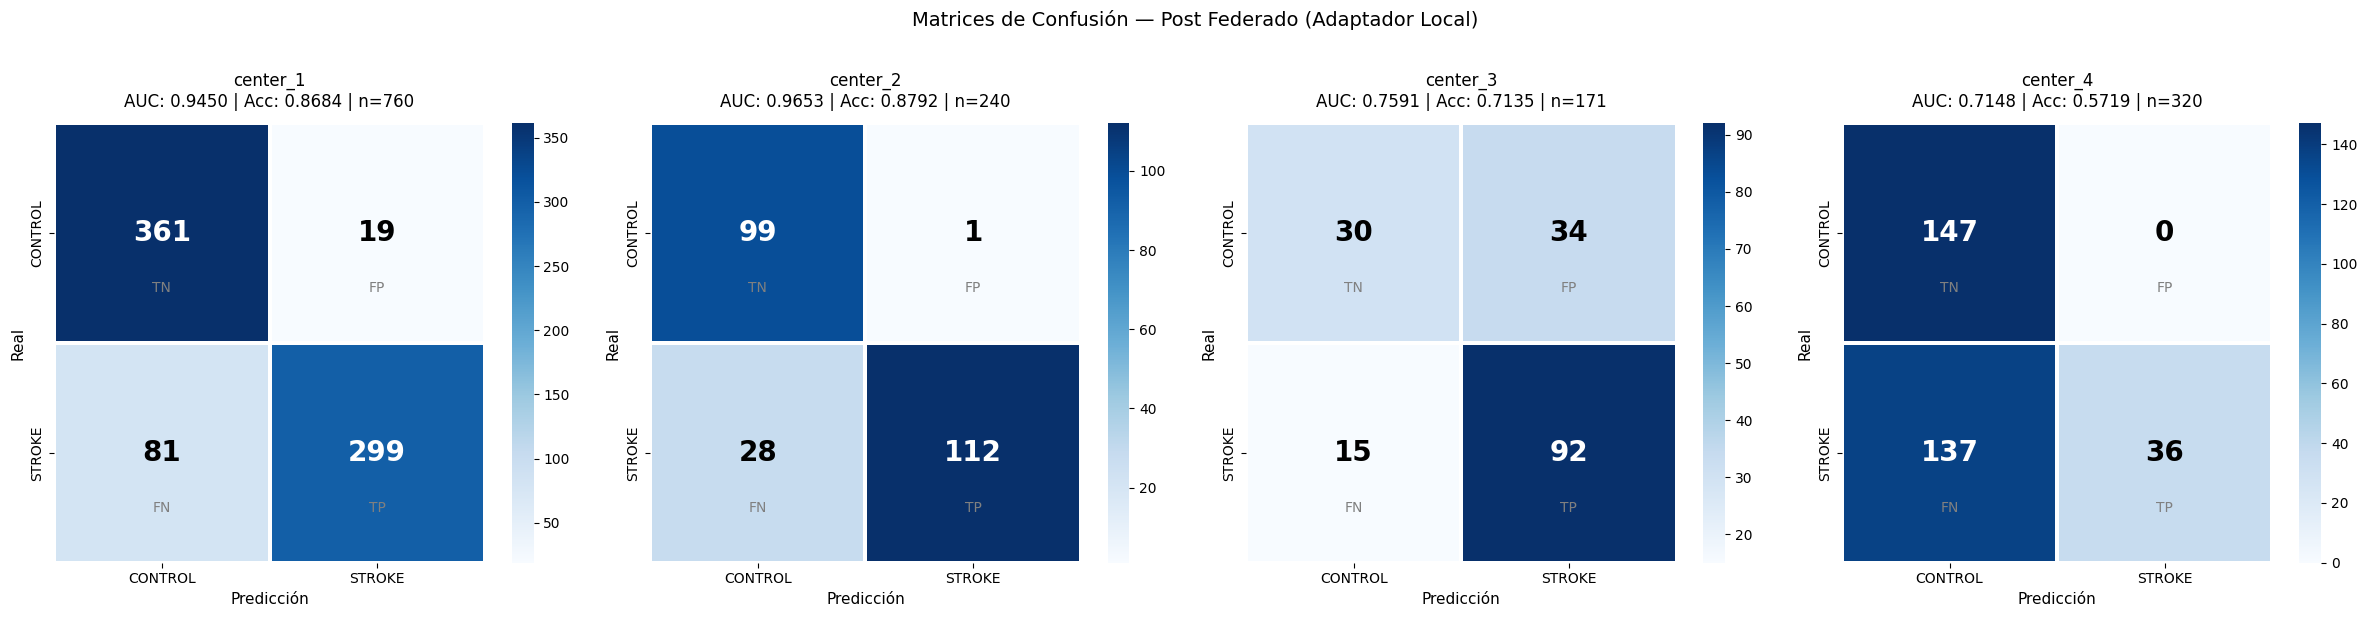

In [42]:
# Matrices de confusión
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, (nombre, res) in zip(axes, resultados.items()):
    cm = res["cm"]
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
                xticklabels=["CONTROL", "STROKE"],
                yticklabels=["CONTROL", "STROKE"],
                linewidths=1.5, linecolor="white", ax=ax)

    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                    ha="center", va="center",
                    fontsize=20, fontweight="bold", color=color)

    etiquetas = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.75, etiquetas[i][j],
                    ha="center", va="center",
                    fontsize=10, color="gray")

    ax.set_title(f"{nombre}\nAUC: {res['auc']:.4f} | Acc: {res['accuracy']:.4f} | n={len(res['labels'])}",
                 fontsize=12, pad=12)
    ax.set_xlabel("Predicción", fontsize=11)
    ax.set_ylabel("Real", fontsize=11)

plt.suptitle("Matrices de Confusión — Post Federado (Adaptador Local)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()